# Reporte de Práctica 3: Suma Máxima de Subarreglo (Divide y Vencerás)
En esta práctica se aborda el problema de encontrar la suma máxima de un subarreglo contiguo dentro de un arreglo de números enteros (positivos y negativos).

Para resolverlo, se utilizó el paradigma Divide y Vencerás, el cual consiste en dividir el problema en subproblemas más pequeños, resolverlos de forma recursiva y combinar sus resultados.

### Planteamiento del Problema
El problema consiste en analizar un arreglo de números enteros A[0..n−1], donde cada elemento puede ser positivo, negativo o cero, y determinar cuál es el subarreglo contiguo no vacío cuya suma de elementos sea máxima.

### Metodología (Divide y Vencerás)

El problema se divide en tres casos:
- Subarreglo completamente en la izquierda
- Subarreglo completamente en la derecha
- Subarreglo que cruza el punto medio

Pasos del algoritmo:

- Dividir el arreglo en dos mitades.
- Resolver recursivamente cada mitad.
- Calcular la suma máxima que cruza el punto medio.
- Retornar el máximo de los tres casos.

## Implementación en Python

In [ ]:
# Librerias
import numpy as np
import time
import sys
import pandas as pd

In [4]:
# Parámetros
#n = 10
#n = 100
#n = 1000
#n = 10000
arr_prueba = [5, 4, -1, 7, 8]
#arr = np.array(range(-n+1, n, 1))
#arr = np.random.randint(-100, 100, n) # (Start, End, # of elements)
#print(f"{arr}")

# Definición de funciones
def max_cruce(arr, izq, mid, der): # Calcula la suma máxima que cruza el punto medio.
  suma_izq = 0                     # Suma de la parte izquierda del arreglo con ciclo for.
  max_suma_izq = -float('inf')
  for i in range(mid, izq - 1, -1):
    suma_izq += arr[i]
    if suma_izq > max_suma_izq:
      max_suma_izq = suma_izq

  suma_der = 0                     # Suma de la parte derecha del arreglo con ciclo for.
  max_suma_der = -float('inf')
  for i in range(mid + 1, der + 1):
    suma_der += arr[i]
    if suma_der > max_suma_der:
      max_suma_der = suma_der

  return max_suma_izq + max_suma_der


def max_subarreglo(arr, izq, der):
  if izq == der:
    return arr[izq]

  mid = (izq + der) // 2

  izqSuma = max_subarreglo(arr, izq, mid)     # Uso de recursividad para dividir el arreglo.
  derSuma = max_subarreglo(arr, mid + 1, der)
  cruceSuma = max_cruce(arr, izq, mid, der)

  return max(izqSuma, derSuma, cruceSuma)     # Devuelve el máximo de cualquiera de los tres casos.

# Uso de la función
print(f"{max_subarreglo(arr_prueba, 0, len(arr_prueba)-1)}")
tamanos = [10, 100, 1000, 10000, 100000, 1000000, 10000000]
resultados = []

for element in tamanos:
  arr = np.array(range(-element+1, element, 1))
  print(f"Arreglo de -{element-1} a {element-1}: {arr}")
  inicio = time.perf_counter()
  suma = max_subarreglo(arr, 0, len(arr)-1)
  fin = time.perf_counter()
  tiempo = fin - inicio
  espacio = sys.getsizeof(arr)
  resultados.append([element,tiempo, espacio, suma])

df = pd.DataFrame(resultados, columns=[
    "Tamaño",
    "Tiempo", "Espacio", "Suma máxima"])

print(df)

23
Arreglo de -9 a 9: [-9 -8 -7 -6 -5 -4 -3 -2 -1  0  1  2  3  4  5  6  7  8  9]
Arreglo de -99 a 99: [-99 -98 -97 -96 -95 -94 -93 -92 -91 -90 -89 -88 -87 -86 -85 -84 -83 -82
 -81 -80 -79 -78 -77 -76 -75 -74 -73 -72 -71 -70 -69 -68 -67 -66 -65 -64
 -63 -62 -61 -60 -59 -58 -57 -56 -55 -54 -53 -52 -51 -50 -49 -48 -47 -46
 -45 -44 -43 -42 -41 -40 -39 -38 -37 -36 -35 -34 -33 -32 -31 -30 -29 -28
 -27 -26 -25 -24 -23 -22 -21 -20 -19 -18 -17 -16 -15 -14 -13 -12 -11 -10
  -9  -8  -7  -6  -5  -4  -3  -2  -1   0   1   2   3   4   5   6   7   8
   9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26
  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44
  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62
  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80
  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98
  99]
Arreglo de -999 a 999: [-999 -998 -997 ...  997  998  999]
Arreglo de -9999 a 9999: [-999

### Análisis Gráfico de Resultados

Para analizar el comportamiento del algoritmo, se generaron gráficas que muestran la relación entre el tamaño del arreglo y el consumo de recursos (tiempo y espacio).

Gráfica de Complejidad Temporal

Se construyó una gráfica donde se representa el tiempo de ejecución en función del tamaño del arreglo.

El código utilizado permite medir el tiempo que tarda el algoritmo en ejecutarse para distintos tamaños de entrada, y posteriormente graficar estos valores.

Descripción de la gráfica:

- En el eje X se representa el tamaño del arreglo.
- En el eje Y se representa el tiempo de ejecución en segundos.
- Se observa cómo el tiempo aumenta conforme crece el tamaño del arreglo.

La gráfica muestra un crecimiento mayor que lineal, lo cual coincide con la complejidad teórica de O(nlogn). Esto se debe a que el algoritmo divide el problema en dos partes en cada llamada recursiva y realiza un trabajo adicional lineal al combinar resultados.

In [6]:
import matplotlib.pyplot as plt

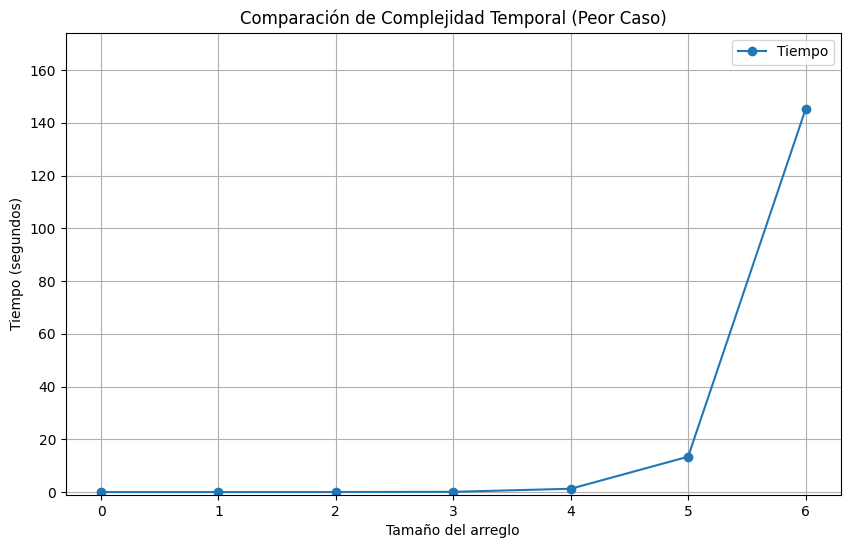

In [7]:
# Plots
plt.figure(figsize=(10,6))
plt.plot(df["Tiempo"], marker="o", label="Tiempo")
plt.xlabel("Tamaño del arreglo")
plt.ylabel("Tiempo (segundos)")
plt.title("Comparación de Complejidad Temporal (Peor Caso)")
plt.legend()
plt.grid()
plt.ylim(-1, df["Tiempo"].max() * 1.2) # Scale to max value with a 10% buffer
plt.show()


### Gráfica de Complejidad Espacial

También se generó una gráfica para analizar el uso de memoria del algoritmo.

Descripción:

- En el eje X se representa el tamaño del arreglo.
- En el eje Y se muestra el espacio utilizado en bytes.
- Se midió el tamaño del arreglo en memoria.

Se observa que el espacio crece de manera lineal respecto al tamaño del arreglo, ya que se almacena directamente en memoria.

Sin embargo, el uso adicional de memoria por la recursividad es bajo, aproximadamente O(logn), debido a la profundidad de la pila de llamadas.

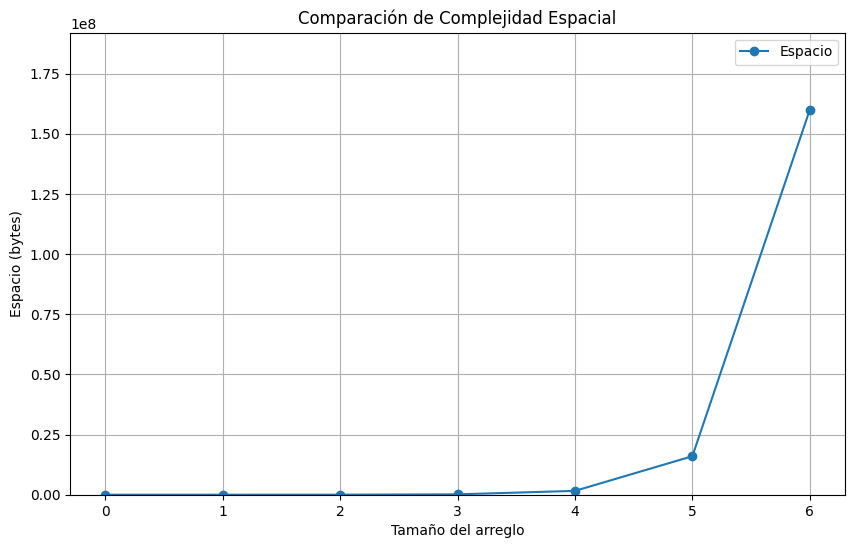

In [8]:
plt.figure(figsize=(10,6))
plt.plot(df["Espacio"], marker="o", label="Espacio")
plt.xlabel("Tamaño del arreglo")
plt.ylabel("Espacio (bytes)")
plt.title("Comparación de Complejidad Espacial")
plt.legend()
plt.grid()
plt.ylim(-1, df["Espacio"].max() * 1.2) # Scale to max value with a 10% buffer
plt.show()

Las gráficas confirman que:

- El tiempo de ejecución sigue el comportamiento esperado de O(nlogn).
- El espacio utilizado crece principalmente por el almacenamiento del arreglo.
- La recursividad no representa un costo significativo en memoria.


### Conclusión

En esta práctica se implementó correctamente el algoritmo de suma máxima de subarreglo utilizando el paradigma de Divide y Vencerás, comprendiendo cómo dividir el problema en partes más pequeñas y combinar sus resultados para obtener la solución óptima. La función max_cruce fue fundamental para considerar los subarreglos que atraviesan el punto medio.

Se determinó que la complejidad temporal del algoritmo es O(n log n), lo que lo hace más eficiente que la fuerza bruta y adecuado para arreglos grandes, manteniendo además un uso de memoria eficiente gracias a la recursividad.

Finalmente, esta actividad permitió reforzar el uso de algoritmos recursivos y el análisis de complejidad, así como entender la importancia del paradigma Divide y Vencerás en la resolución de problemas. Además, este tipo de solución puede aplicarse en distintos contextos donde se requiera encontrar valores óptimos dentro de grandes conjuntos de datos.